In [1]:
# Importing all the necessary libraries
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.coordinates import match_coordinates_sky
import math as math
from astropy.io import fits
from astropy.table import Table
import os
import seaborn as sns
from IPython.display import clear_output
import astropy.units as u
from sklearn.neighbors import KernelDensity,KNeighborsClassifier
import os
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler, Normalizer
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, confusion_matrix, matthews_corrcoef, silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, RandomizedSearchCV, GridSearchCV, StratifiedKFold, train_test_split
import pickle
import missingno as msno
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.cluster import KMeans
import subprocess
import joblib
import requests
from PIL import Image
import matplotlib.patches as patches
from sklearn.preprocessing import StandardScaler, RobustScaler, Normalizer
from collections import Counter
from astropy.visualization.wcsaxes import SphericalCircle
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor


pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", None)

SEED = 333
np.random.seed(SEED)

In [2]:
from auxiliar import *

In [ ]:
main_columns = ["RA", "DEC"] + mags_petro_c + mags_auto_c + FWHM_IMAGE + morphology + positions + flags + colors_r + Mg

columns_not_important = mags_petro+mags_auto+mags_aper_6+mags_aper_3+mags_iso+mags_e_iso+mags_e_aper_3+flux_auto+flux_iso+flux_petro+flux_err_auto+flux_err_iso+flux_aper_3+flux_aper_6+flux_err_auto+flux_err_iso+flux_err_petro+flux_err_aper_3+flux_err_aper_6+FWHM_WORLD+class_stars+isoarea_world+isoarea_image+flux_max+snr_win+treshold+mu_treshold+mu_max+background


# Paths originais
path_run1_original = fr"/work1/pierre/Faculdade_teiu/Dados/fornax/runs_rodrigo/arqs_origins/run1.fits"
path_UCDs_classicas_fornax = fr"/work1/pierre/Faculdade_teiu/Dados/UCDs/UCDs_classicas_fornax.fits"

# Background confirmed
path_background_objects = fr"/work1/pierre/Faculdade_teiu/Dados/fornax/FDS_BACKGROUND.fits"

#####################


path_run1_correct_main = fr"/work1/pierre/Faculdade_teiu/run1_correct_main.parquet"
# run1_correct_main = pd.read_parquet(path_run1_correct_main)


# path_run1_correct_gaiadr3_vacs_lili_specz = fr"/work1/pierre/Faculdade_teiu/run1_correct_gaiadr3_vacs_lili_specz.parquet"
# run1_correct_gaiadr3_vacs_lili_specz = pd.read_parquet(path_run1_correct_gaiadr3_vacs_lili_specz)

run1_correct_gaiadr3_vacs_lili_specz_photoz = pd.read_parquet(fr"/work1/pierre/Faculdade_teiu/run1_correct_specz_photoz.parquet")

In [50]:
fornax_objects_ra_dec = fits_open(fr'fornax_objects_ra_dec.fits')

UCDs_fornax_path = fr"/work1/pierre/Faculdade_teiu/Dados/UCDs/UCDs_run1_properties.csv"
UCDs_fornax = pd.read_csv(UCDs_fornax_path)

UCDs_fornax = make_colors(UCDs_fornax, colors, mag_type='APER_6_c')

In [ ]:
run1_correct_specz_photozs_valid = run1_correct_specz_photozs.query(fr"z>=0")

# Salvar
run1_correct_specz_photozs_valid.to_parquet("run1_correct_gaiadr3_vacs_lili_specz_valid.parquet")

In [3]:
run1_correct_gaiadr3_vacs_lili_specz_valid = pd.read_parquet("run1_correct_gaiadr3_vacs_lili_specz_valid.parquet")

# Ajustando dados #

In [5]:
mags_train = mags_aper_6_c

# Remover as linhas que contêm NaN em qualquer uma dessas colunas
df_valid = run1_correct_gaiadr3_vacs_lili_specz_valid.copy()
df_valid[mags_train] = df_valid[mags_train].applymap(lambda x: np.nan if x > 30 else x)

df_filtered = df_valid.dropna(subset=mags_train)


print(fr" tamanho lista valroes mags sem nan = {len(df_filtered)}")


df_train_filtered = df_filtered.query(fr"z>=0.003 and R_APER_6_c>=15 and R_APER_6_c<=22.5")
# df_train_filtered = df_filtered.query(fr"z>=0.002 and z<=0.4 and R_APER_6_c>=15 and R_APER_6_c<=22.5")
df_train_filtered = make_colors(df_train_filtered, colors, mag_type="APER_6_c")

print(fr" tamanho lista valores depois do cortes = {len(df_train_filtered)}")

/tmp/ipykernel_1293356/808170449.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_valid[mags_train] = df_valid[mags_train].applymap(lambda x: np.nan if x > 30 else x)


 tamanho lista valroes mags sem nan = 21973
 tamanho lista valores depois do cortes = 12296


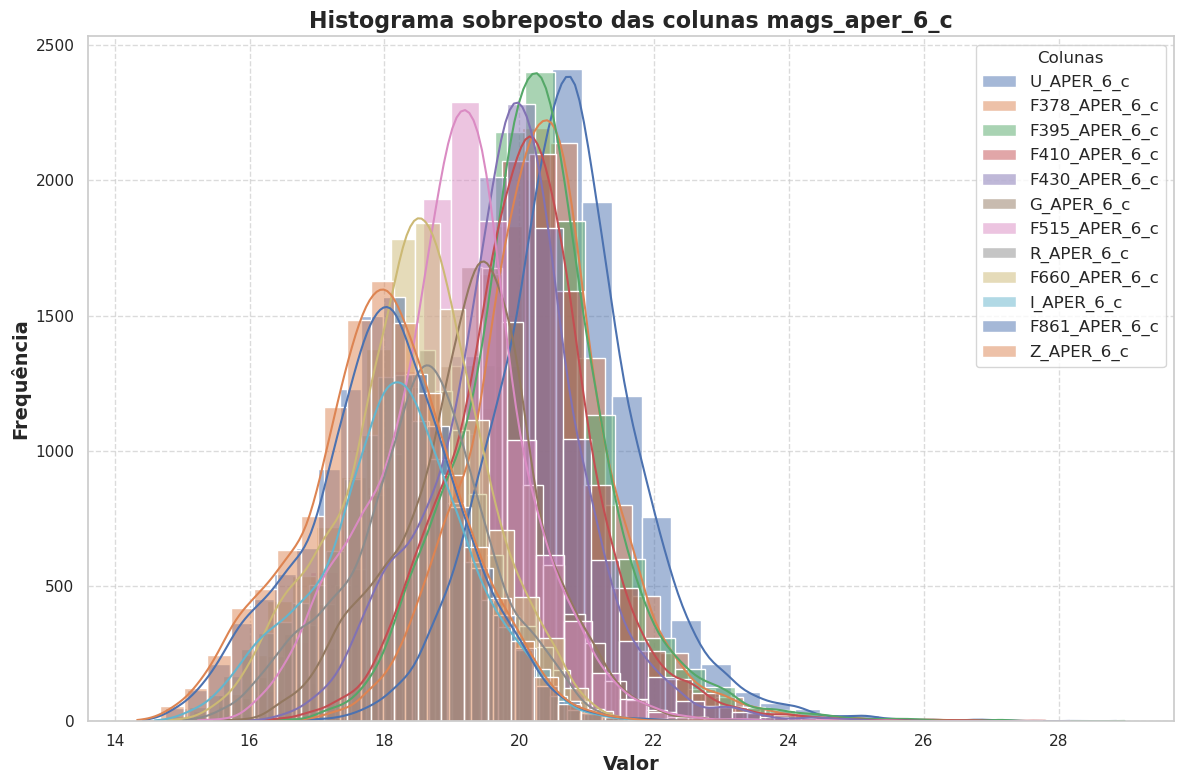

In [27]:
# Configurar o estilo do seaborn
sns.set(style="whitegrid")

# Criar um único histograma sobreposto para todas as colunas em mags_petro_c
plt.figure(figsize=(12, 8))

for column in mags_aper_6_c:
    sns.histplot(df_train_filtered[column], bins=30, kde=True, label=column, alpha=0.5)

plt.title('Histograma sobreposto das colunas mags_aper_6_c', fontsize=16, fontweight='bold')
plt.xlabel('Valor', fontsize=14, fontweight='bold')
plt.ylabel('Frequência', fontsize=14, fontweight='bold')
plt.legend(title='Colunas', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Treinamento #

In [ ]:
# Supondo que df_valid e colors estejam definidos
df_train = df_train_filtered.copy()

# Colunas para treino
columns_train = colors

# Para treino, usar no df as colunas columns_train
x_train = df_train[columns_train]
y_train = df_train['z']

# Separar os dados em treino e teste
treino_x, teste_x, treino_y, teste_y = train_test_split(x_train, y_train, 
                                                        random_state=SEED,
                                                        test_size=0.20)

# Criar o normalizador
scaler = MinMaxScaler()

# Ajustar e transformar os dados de treino
treino_x_norm = scaler.fit_transform(treino_x)

# Parâmetros para a busca em grade
param_grid = {
    'n_neighbors': range(16, 25, 1),
    'metric': ['euclidean', 'manhattan', 'chebyshev', 'minkowski'],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'leaf_size': [10]
}

# Create and train the KNN regressor
knn_regressor = KNeighborsRegressor()

# Configurando a busca em grade com validação cruzada
grid_search = GridSearchCV(estimator=knn_regressor, param_grid=param_grid, cv=5, n_jobs=-1)

# Executando a busca em grade
grid_search.fit(treino_x_norm, treino_y)

# Imprimindo os melhores parâmetros encontrados
print("Melhores parâmetros:", grid_search.best_params_)

# Rodando o melhor modelo
best_model = grid_search.best_estimator_

Melhores parâmetros: {'algorithm': 'auto', 'leaf_size': 10, 'metric': 'manhattan', 'n_neighbors': 16, 'weights': 'distance'}


Mean Squared Error: 0.045400199992981505
R-squared: 0.6492938053985207


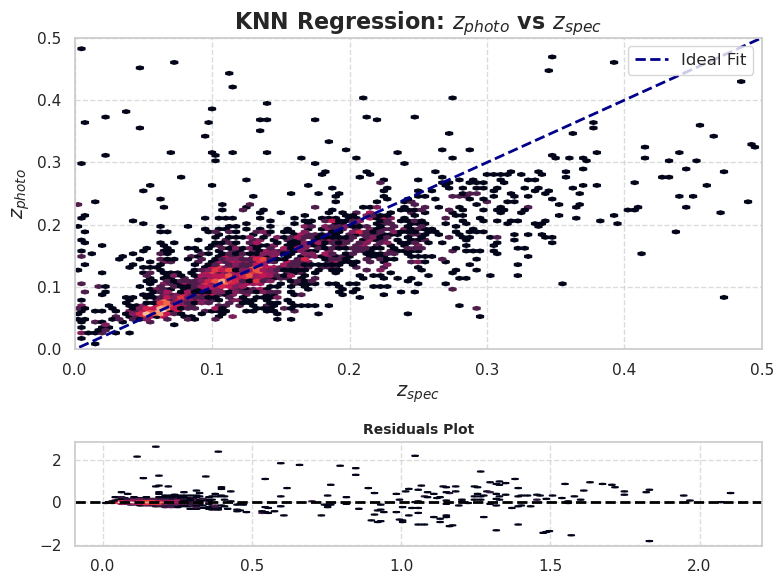

In [ ]:
df_train = df_train_filtered.copy()

# Nome do modelo no final do nome
name_model = 'photoz_knn'

# Colunas para treino
columns_train = colors

# Para treino, usar no df as colunas columns_train
x_train = df_train[columns_train]
y_train = df_train['z']


# Separar os dados em treino e teste
treino_x, teste_x, treino_y, teste_y = train_test_split(x_train, y_train, 
                                                        random_state=SEED,
                                                        test_size=0.20)
# Criar o normalizador
scaler = MinMaxScaler()
# scaler = StandardScaler()

# Ajustar e transformar os dados de treino
x_norm = scaler.fit_transform(treino_x)

# Salvar o scaler
with open(f'models/scaler_{name_model}.pkl', 'wb') as file:
    pickle.dump(scaler, file)

# Transformar os dados de teste
teste_x_norm = scaler.transform(teste_x)

# Create and train the KNN regressor
knn_regressor = KNeighborsRegressor(n_neighbors=16, metric='manhattan', weights='distance', algorithm='auto', leaf_size=10)
knn_regressor.fit(x_norm, treino_y)

# Salvar o modelo
with open(f'models/model_{name_model}.pkl', 'wb') as file:
    pickle.dump(knn_regressor, file)

# Make predictions on the test data
y_pred = knn_regressor.predict(teste_x_norm)

# Evaluate the model
mse = mean_squared_error(teste_y, y_pred)
r2 = r2_score(teste_y, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')


# Visualize the results using the first feature column
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={'height_ratios': [3, 1]})

max_z = 0.5
# Primeiro gráfico (photoz vs z)
hb1 = ax1.hexbin(teste_y, y_pred, gridsize=100, bins='log', extent=(0, max_z, 0, max_z))
ax1.plot([min(teste_y), max(teste_y)], [min(teste_y), max(teste_y)], color='darkblue', linestyle='--', linewidth=2, label='Ideal Fit')
# ax1.axhline(y=0.1, color='red', linestyle='-', linewidth=1, label='Cut_BG')
# ax1.axvline(x=0.005, color='red', linestyle='-', linewidth=1)
ax1.set_title(r'KNN Regression: $z_{photo}$ vs $z_{spec}$', fontsize=16, fontweight='bold')
ax1.set_xlabel(r'$z_{spec}$', fontsize=14, fontweight='bold')
ax1.set_ylabel(r'$z_{photo}$', fontsize=14, fontweight='bold')
ax1.set_xlim(0, max_z)
ax1.set_ylim(0, max_z)
ax1.legend(fontsize=12, loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.7)

# Adicionar colorbar ao primeiro gráfico
# cbar1 = fig.colorbar(hb1, ax=ax1, orientation='vertical', shrink=0.8)
# cbar1.set_label('Counts', fontsize=12)

# Segundo gráfico (Residuals Plot)
residuals = teste_y - y_pred
hb2 = ax2.hexbin(y_pred, residuals, gridsize=100, bins='log', label='photoz vs z')
ax2.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax2.set_title('Residuals Plot', fontsize=10, fontweight='bold')
# ax2.set_xlabel('Predicted photoz', fontsize=14, fontweight='bold')
# ax2.set_ylabel('Residuals', fontsize=14, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.7)

# Adicionar colorbar ao segundo gráfico
# cbar2 = fig.colorbar(hb2, ax=ax2, orientation='vertical', shrink=0.8, format='%.0e')
# cbar2.set_label('Counts', fontsize=12)

plt.tight_layout()
plt.show()

Mean Squared Error: 0.051246827317942244
R-squared: 0.6041299422281603
Sigma_NMAD: 0.030917645951104872
Fração de Outliers: 0.08414634146341464


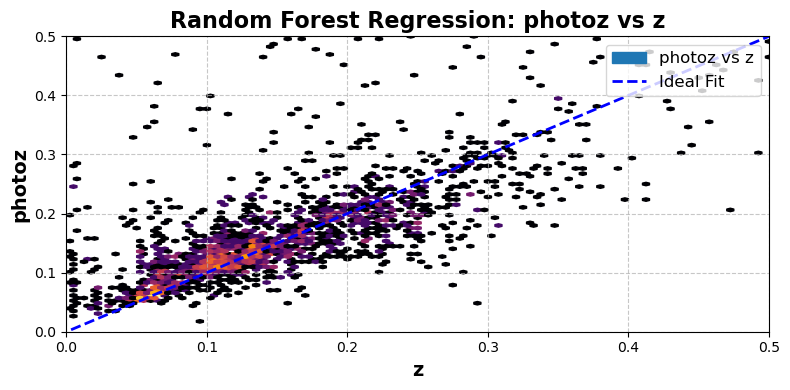

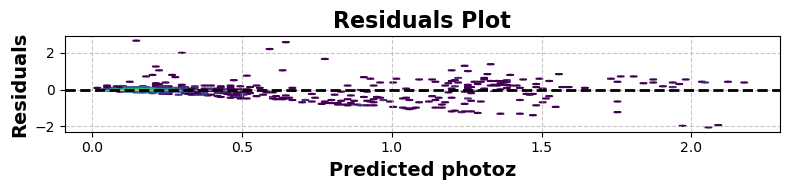

In [9]:
# Com Random Forest

# Supondo que df_train_filtered, mags_petro_c e colors estejam definidos
df_train = df_train_filtered.copy()

# Nome do modelo no final do nome
name_model = 'photoz_rf'

# Run RF
columns_train = colors

# Para treino, usar no df as colunas columns_train
x_train = df_train[columns_train]
y_train = df_train['z']

# Separar os dados em treino e teste
treino_x, teste_x, treino_y, teste_y = train_test_split(x_train, y_train, 
                                                        random_state=SEED,
                                                        test_size=0.20)

# Criar o normalizador
scaler = MinMaxScaler()

# Ajustar e transformar os dados de treino
x_norm = scaler.fit_transform(treino_x)

# Salvar o scaler
with open(f'models/scaler_{name_model}.pkl', 'wb') as file:
    pickle.dump(scaler, file)

# Transformar os dados de teste
teste_x_norm = scaler.transform(teste_x)

# Create and train the Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=50, random_state=SEED)
rf_regressor.fit(x_norm, treino_y)

# Salvar o modelo
with open(f'models/model_{name_model}.pkl', 'wb') as file:
    pickle.dump(rf_regressor, file)

# Make predictions on the test data
y_pred = rf_regressor.predict(teste_x_norm)

# Evaluate the model
mse = mean_squared_error(teste_y, y_pred)
r2 = r2_score(teste_y, y_pred)

# Função para calcular sigma_NMAD
def sigma_nmad(y_true, y_pred):
    return 1.48 * np.median(np.abs((y_true - y_pred) / (1 + y_true)))

# Função para calcular a fração de outliers
def fraction_outliers(y_true, y_pred, threshold=0.15):
    residuals = np.abs((y_true - y_pred) / (1 + y_true))
    return np.mean(residuals > threshold)

# Calcular sigma_NMAD
sigma_nmad_value = sigma_nmad(teste_y, y_pred)

# Calcular a fração de outliers (usando threshold de 0.15 como padrão)
outlier_fraction = fraction_outliers(teste_y, y_pred, threshold=0.15)

# Exibir os resultados
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')
print(f'Sigma_NMAD: {sigma_nmad_value}')
print(f'Fração de Outliers: {outlier_fraction}')

# Visualize the results using the first feature column
plt.figure(figsize=(8, 4))

max_z = 0.5
# plt.scatter(teste_y, y_pred, color='red', label='photoz vs z', alpha=0.6, edgecolors='w', s=50)
plt.hexbin(teste_y, y_pred, gridsize=100, bins='log', extent=(0, max_z, 0, max_z), label='photoz vs z', cmap='inferno')
plt.plot([min(teste_y), max(teste_y)], [min(teste_y), max(teste_y)], color='blue', linestyle='--', linewidth=2, label='Ideal Fit')
plt.title('Random Forest Regression: photoz vs z', fontsize=16, fontweight='bold')
plt.xlabel('z', fontsize=14, fontweight='bold')
plt.ylabel('photoz', fontsize=14, fontweight='bold')
plt.xlim(0, max_z)
plt.ylim(0, max_z)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Visualize the residuals
residuals = teste_y - y_pred
plt.figure(figsize=(8, 2))
# plt.scatter(y_pred, residuals, color='purple', alpha=0.6, edgecolors='w', s=50)
plt.hexbin(y_pred, residuals, gridsize=100, bins='log', label='photoz vs z')
plt.axhline(y=0, color='black', linestyle='--', linewidth=2)
plt.title('Residuals Plot', fontsize=16, fontweight='bold')
plt.xlabel('Predicted photoz', fontsize=14, fontweight='bold')
plt.ylabel('Residuals', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Comparar Photoz com os do erik

In [7]:
run1_correct_gaiadr3_vacs_lili_specz_photoz_valid = run1_correct_gaiadr3_vacs_lili_specz_photoz.query(fr"z>=0 and zml>=0")

print(len(run1_correct_gaiadr3_vacs_lili_specz_photoz_valid))

23695


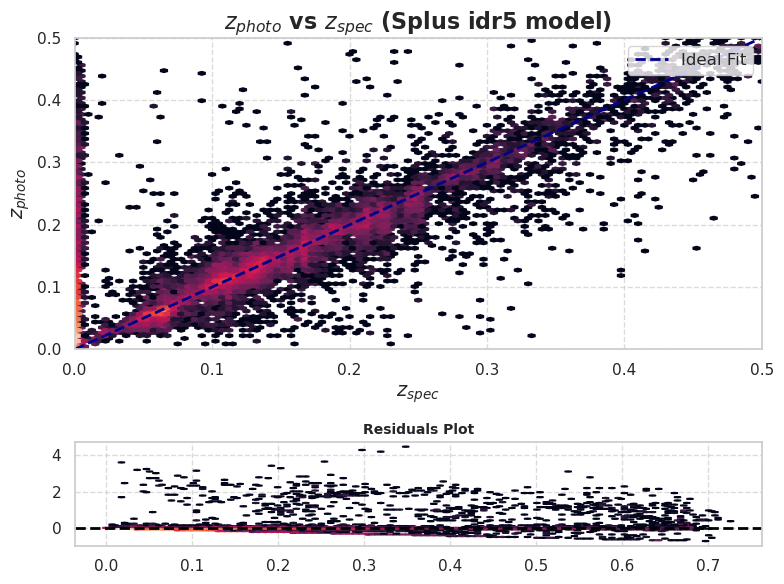

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={'height_ratios': [3, 1]})

x = run1_correct_gaiadr3_vacs_lili_specz_photoz_valid['z']
y = run1_correct_gaiadr3_vacs_lili_specz_photoz_valid['zml']

max_z = 0.5

# Primeiro gráfico (photoz vs z)
hb1 = ax1.hexbin(x, y, gridsize=100, bins='log', extent=(0, max_z, 0, max_z))
ax1.plot([min(x), max(x)], [min(x), max(x)], color='darkblue', linestyle='--', linewidth=2, label='Ideal Fit')
ax1.set_title(r'$z_{photo}$ vs $z_{spec} $ (Splus idr5 model)', fontsize=16, fontweight='bold')
ax1.set_xlabel(r'$z_{spec}$', fontsize=14, fontweight='bold')
ax1.set_ylabel(r'$z_{photo}$', fontsize=14, fontweight='bold')
ax1.set_xlim(0, max_z)
ax1.set_ylim(0, max_z)
ax1.legend(fontsize=12, loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.7)

# Segundo gráfico (Residuals Plot)
residuals = x - y
hb2 = ax2.hexbin(y, residuals, gridsize=100, bins='log', label='photoz vs z')
ax2.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax2.set_title('Residuals Plot', fontsize=10, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


# Aplicando modelos nas candidatas #

In [3]:
candidatas_prob = pd.read_parquet(fr"/work1/pierre/Faculdade_teiu/github_teiu/ucds_candidates/run1_train_predict_m2.parquet")

In [6]:
run1_correct_gaiadr3_vacs_lili_specz_photoz = make_colors(run1_correct_gaiadr3_vacs_lili_specz_photoz, colors, mag_type="APER_6_c")

In [7]:
# Fazer as previsoes
model = 'photoz_rf'

# Carregar o scaler salvo
with open(f'models/scaler_{model}.pkl', 'rb') as file:
    scaler = pickle.load(file)

# Carregar o modelo salvo
with open(f'models/model_{model}.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

df_preve = run1_correct_gaiadr3_vacs_lili_specz_photoz.copy()
df_photoz = run1_correct_gaiadr3_vacs_lili_specz_photoz.copy()

# Definir as colunas que você quer ler e a ordem que você quer
columns_predict = colors

# Reordenar as colunas
df_preve = df_preve[columns_predict]

# Ajustar e transformar os dados
candidates_norm = scaler.transform(df_preve)

# Make predictions on the test data
predict_z = loaded_model.predict(candidates_norm)

# Armazenar as previsões de ser da classe 1
# all_predictions_prob = predictp[:, 1]

df_photoz['photo_z'] = predict_z

In [9]:
# Salvar
save_as_fits(df_photoz, '/work1/pierre/Faculdade_teiu/run1_correct_specz_photozs.fits')
df_photoz.to_parquet('/work1/pierre/Faculdade_teiu/run1_correct_specz_photozs.parquet')

Arquivo FITS criado com sucesso: /work1/pierre/Faculdade_teiu/run1_correct_specz_photozs.fits


In [54]:
# Fazer as previsoes
model = 'photoz_rf'

# Carregar o scaler salvo
with open(f'models/scaler_{model}.pkl', 'rb') as file:
    scaler = pickle.load(file)

# Carregar o modelo salvo
with open(f'models/model_{model}.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

df_preve = UCDs_fornax.copy()
df_photoz = UCDs_fornax.copy()

# Definir as colunas que você quer ler e a ordem que você quer
columns_ucds_predict = colors

# Reordenar as colunas
df_preve = df_preve[columns_ucds_predict]

# Ajustar e transformar os dados
candidates_norm = scaler.transform(df_preve)

# Make predictions on the test data
predict_z = loaded_model.predict(candidates_norm)

# Armazenar as previsões de ser da classe 1
# all_predictions_prob = predictp[:, 1]

df_photoz['photo_z'] = predict_z


df_photoz[['Name','photo_z', 'zml', 'z','PSS','PGal']]

,Name,photo_z,zml,z,PSS,PGal
0,"UCD3, F-19",0.078846,0.036245,0.005306,0.000000,1.000000
1,UCD1,0.093976,0.089327,0.005174,0.000673,0.999027
2,F-24,0.081690,0.048755,0.006264,0.000348,0.999552
3,UCD5,0.037098,0.040755,0.004520,0.008678,0.990410
4,F-1a,0.217425,NaN,NaN,0.000129,0.999794
5,F-9,0.096540,0.073755,0.005804,0.248407,0.651112
6,F-5,0.063864,NaN,0.005678,0.003661,0.994335
7,F-6,0.103530,NaN,0.003752,0.986570,0.012449
8,F-7,0.195412,0.167245,NaN,0.998054,0.000078
9,F-12,0.071137,NaN,0.005517,0.103077,0.894921


In [ ]:
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('y = x')
plt.grid(True)
plt.show()

: 